In [ ]:
#instalar dependencias
!pip install ultralytics roboflow -q

In [ ]:
#cargar el dataset desde el zip incluido en el repo
import zipfile
import os

ZIP_PATH = "dataset/sign_recognition_picarx.yolov8"   # zip del dataset
DATASET_DIR = "dataset_extraido"

if not os.path.exists(DATASET_DIR):
    with zipfile.ZipFile(ZIP_PATH) as z:
        z.extractall(DATASET_DIR)

print("Dataset cargado desde:", DATASET_DIR)


Dataset cargado desde: dataset_extraido


### EDA

In [4]:
#EDA 1: leer data.yaml y ver las clases
import yaml, os

with open(f"{DATASET_DIR}/data.yaml") as f:
    data_cfg = yaml.safe_load(f)

class_names = data_cfg['names']
print("Clases:", class_names)
print("Cantidad de clases:", data_cfg['nc'])

Clases: ['avance', 'ceder', 'contramano', 'derecha', 'izquierda', 'pare', 'peaton', 'peligro', 'vel20', 'vel30']
Cantidad de clases: 10


In [5]:
#EDA 2: cantidad de imagenes por split (train/valid/test)
splits = ['train', 'valid', 'test']

for split in splits:
    img_dir = f"{DATASET_DIR}/{split}/images"
    if os.path.exists(img_dir):
        n = len([f for f in os.listdir(img_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
        print(f"{split}: {n} imagenes")
    else:
        print(f"{split}: no existe")

train: 1842 imagenes
valid: 175 imagenes
test: 87 imagenes


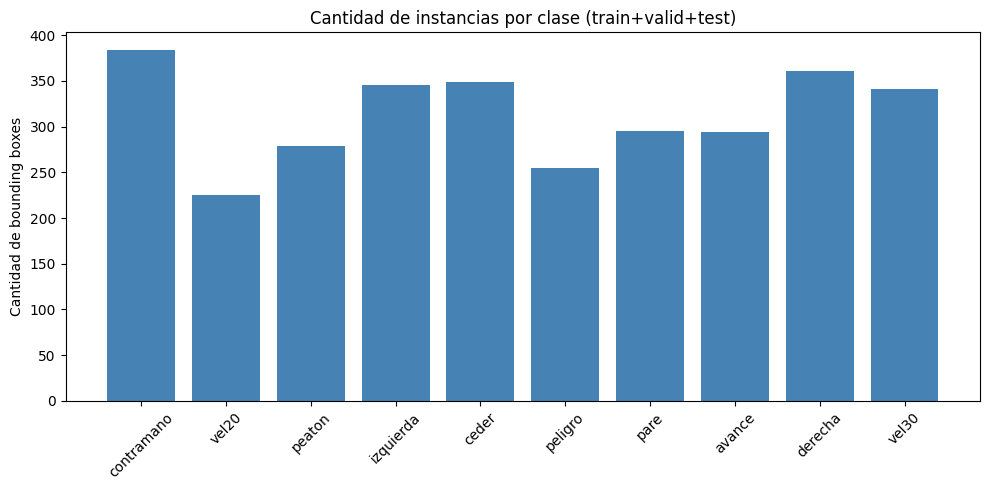

In [6]:
#EDA 3: cantidad de instancias (bounding boxes) por clase, en todo el dataset
import matplotlib.pyplot as plt
from collections import Counter

counts = Counter()

for split in splits:
    label_dir = f"{DATASET_DIR}/{split}/labels"
    if not os.path.exists(label_dir):
        continue
    for fname in os.listdir(label_dir):
        if not fname.endswith('.txt'):
            continue
        with open(os.path.join(label_dir, fname)) as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                class_id = int(line.split()[0])
                counts[class_names[class_id]] += 1

plt.figure(figsize=(10, 5))
plt.bar(counts.keys(), counts.values(), color='steelblue')
plt.title("Cantidad de instancias por clase (train+valid+test)")
plt.ylabel("Cantidad de bounding boxes")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

            train  valid  test
avance        255     24    15
ceder         324     15    10
contramano    339     33    12
derecha       321     31     9
izquierda     303     29    14
pare          252     26    17
peaton        243     23    13
peligro       216     28    11
vel20         201     14    10
vel30         297     30    14


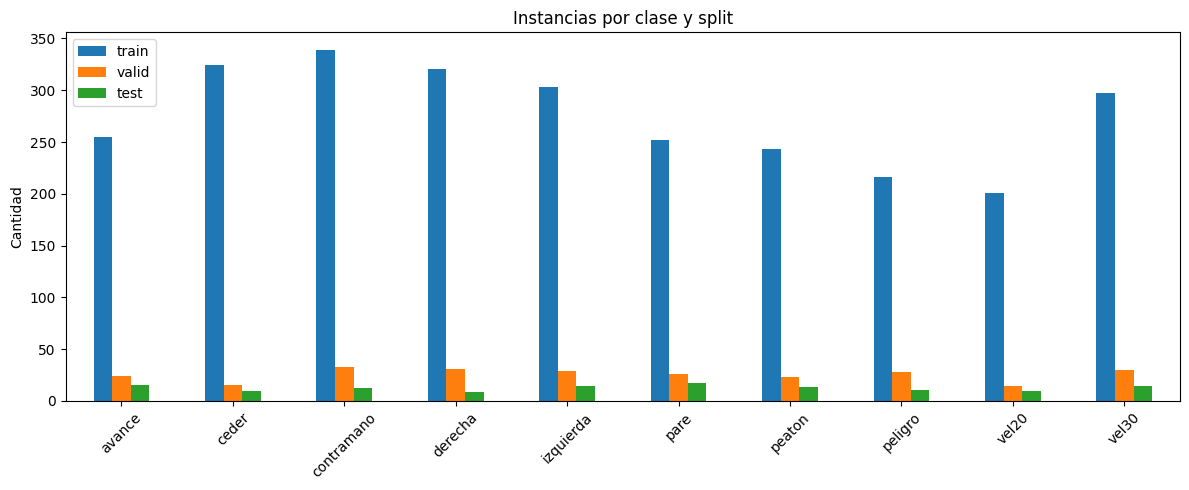

In [7]:
#EDA 4: instancias por clase separado por split (para ver si algun split quedo desbalanceado)
import pandas as pd

split_counts = {split: Counter() for split in splits}

for split in splits:
    label_dir = f"{DATASET_DIR}/{split}/labels"
    if not os.path.exists(label_dir):
        continue
    for fname in os.listdir(label_dir):
        if not fname.endswith('.txt'):
            continue
        with open(os.path.join(label_dir, fname)) as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                class_id = int(line.split()[0])
                split_counts[split][class_names[class_id]] += 1

df = pd.DataFrame(split_counts).fillna(0).astype(int)
df = df.reindex(class_names)
print(df)

df.plot(kind='bar', figsize=(12, 5))
plt.title("Instancias por clase y split")
plt.ylabel("Cantidad")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

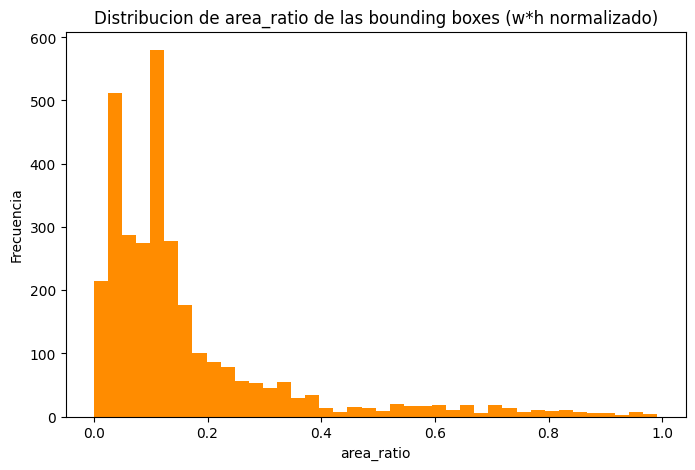

In [8]:
#EDA 5: distribucion del area_ratio de las cajas (w*h normalizado)
import numpy as np

areas = []

for split in splits:
    label_dir = f"{DATASET_DIR}/{split}/labels"
    if not os.path.exists(label_dir):
        continue
    for fname in os.listdir(label_dir):
        if not fname.endswith('.txt'):
            continue
        with open(os.path.join(label_dir, fname)) as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                parts = line.split()
                w, h = float(parts[3]), float(parts[4])
                areas.append(w * h)

areas = np.array(areas)

plt.figure(figsize=(8, 5))
plt.hist(areas, bins=40, color='darkorange')
plt.title("Distribucion de area_ratio de las bounding boxes (w*h normalizado)")
plt.xlabel("area_ratio")
plt.ylabel("Frecuencia")
plt.show()

In [9]:
#EDA 6: dimensiones de las imagenes del set de train
import cv2

train_img_dir = f"{DATASET_DIR}/train/images"
train_label_dir = f"{DATASET_DIR}/train/labels"

widths, heights = [], []
for fname in os.listdir(train_img_dir):
    img = cv2.imread(os.path.join(train_img_dir, fname))
    if img is None:
        continue
    h, w = img.shape[:2]
    widths.append(w)
    heights.append(h)

print(f"Ancho: min={min(widths)} max={max(widths)}  |  Alto: min={min(heights)} max={max(heights)}")

Ancho: min=640 max=640  |  Alto: min=640 max=640


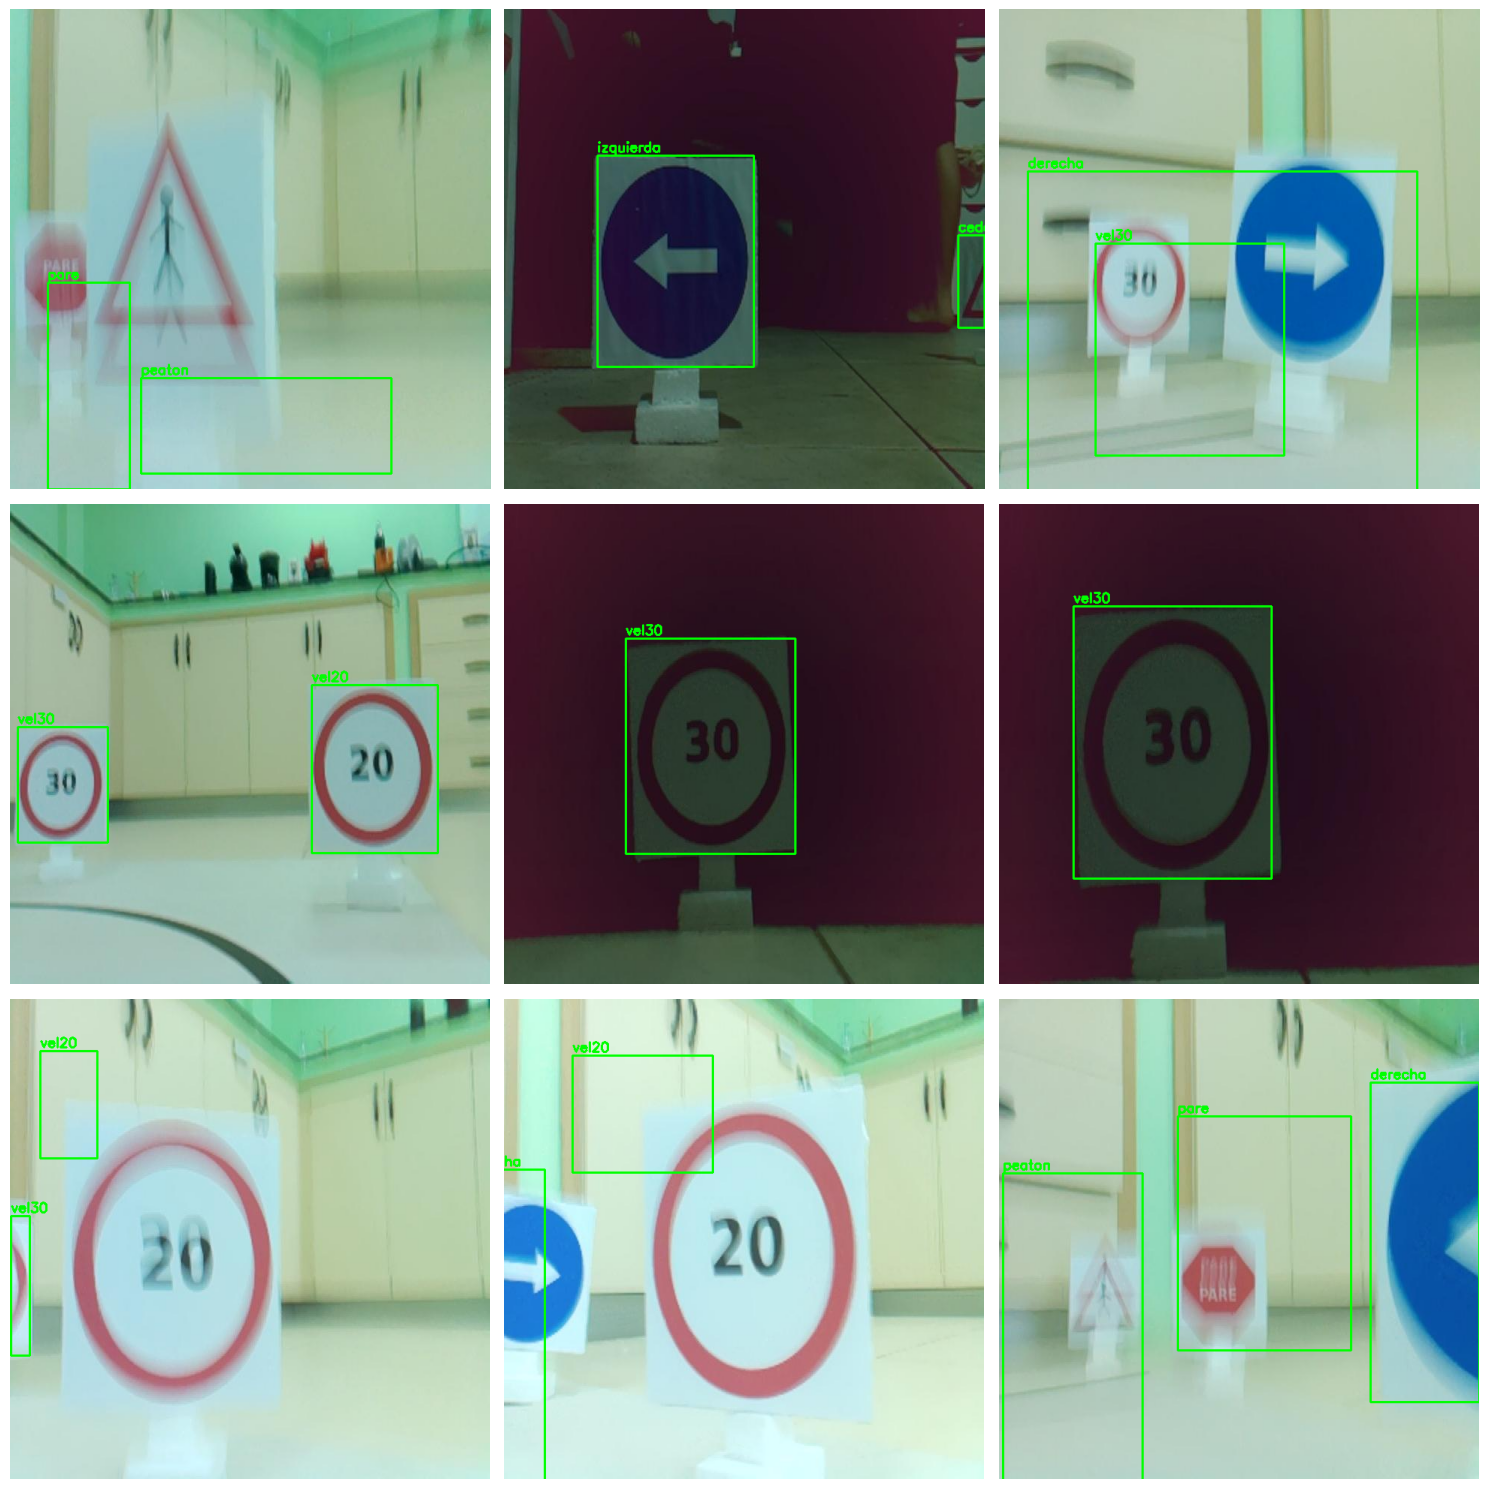

In [10]:
#EDA 7: muestra visual de imagenes con sus anotaciones dibujadas
import random

def draw_boxes(img_path, label_path, class_names):
    img = cv2.imread(img_path)
    h, w = img.shape[:2]
    if os.path.exists(label_path):
        with open(label_path) as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                parts = line.split()
                cls_id = int(parts[0])
                cx, cy, bw, bh = map(float, parts[1:5])
                x1 = int((cx - bw / 2) * w)
                y1 = int((cy - bh / 2) * h)
                x2 = int((cx + bw / 2) * w)
                y2 = int((cy + bh / 2) * h)
                cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
                cv2.putText(img, class_names[cls_id], (x1, max(y1 - 5, 0)),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

all_imgs = os.listdir(train_img_dir)
sample_files = random.sample(all_imgs, min(9, len(all_imgs)))

fig, axes = plt.subplots(3, 3, figsize=(15, 15))
for ax, fname in zip(axes.flatten(), sample_files):
    img_path = os.path.join(train_img_dir, fname)
    label_path = os.path.join(train_label_dir, fname.rsplit('.', 1)[0] + '.txt')
    img = draw_boxes(img_path, label_path, class_names)
    ax.imshow(img)
    ax.axis('off')
plt.tight_layout()
plt.show()

### Entrenamiento

In [ ]:
#entrenar (SIN flip horizontal, para no corromper izquierda/derecha)
from ultralytics import YOLO

model = YOLO("yolov8n.pt")   # nano: el más liviano, ideal para correr después en la Pi

results = model.train(
    data=f"{DATASET_DIR}/data.yaml",
    epochs=100,
    imgsz=640,
    batch=16,
    patience=20,        # corta antes si no mejora en 20 epochs (evita overfitting con dataset chico)
    project="senales_trafico",
    name="entrenamiento_sin_flip",
    device=0,            # usa la GPU de Colab
    fliplr=0.0           # desactiva el flip horizontal: evita que izquierda/derecha se corrompan entre si
)

In [ ]:
#validar
metrics = model.val()
print(metrics)

In [ ]:
#exportar a formato liviano para la Pi
model.export(format="ncnn")   # recomendado para Raspberry Pi 5 (más rápido que .pt puro)
# alternativa: model.export(format="onnx")

In [ ]:
model.export(format="onnx")

In [ ]:
from ultralytics import YOLO

model = YOLO("/content/runs/detect/senales_trafico/entrenamiento_sin_flip/weights/best.pt")
model.export(format="tflite")

In [ ]:
import shutil
from google.colab import files

carpeta = '/content/runs/detect/senales_trafico/entrenamiento_sin_flip'
shutil.make_archive('/content/entrenamiento_sin_flip', 'zip', carpeta)
files.download('/content/entrenamiento_sin_flip.zip')